Gaddiel Irakoze

## [Fraud in Wine](https://en.wikipedia.org/wiki/Wine_fraud)

Wine fraud relates to the commercial aspects of wine. The most prevalent type of fraud is one where wines are adulterated, usually with the addition of cheaper products and sometimes with harmful chemicals and sweeteners. Counterfeiting and the relabelling of inferior and cheaper wines to more expensive brands is another common type of wine fraud.

## Project Goals

A distribution company that was recently a victim of fraud completed an audit of wine samples through chemical analysis. The company exports high quality wines, but a supplier attempted to pass off cheaper wine as higher grade wine. The goal here is to build a model that can help detect whether a sample is `Legit` or `Fraud`.

Data source: P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis, *Modeling wine preferences by data mining from physicochemical properties*, Decision Support Systems, 47(4):547-553, 2009.


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA

# SMOTE available for optional oversampling in the NN path
from imblearn.over_sampling import SMOTE

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

### Loading the dataset

We start by loading the course dataset and checking its shape, column names, and first rows. This is useful because it tells us whether the target is already binary and whether there are categorical features that need encoding.

In [2]:
df = pd.read_csv('./data/wine_fraud.csv')
#df = pd.read_csv('/content/wine_fraud.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


Let's check the unique values in the target column (`quality`).

In [3]:
df['quality'].value_counts()

,count
quality,
Legit,6251
Fraud,246


### Exploratory Data Analysis

The next plots give a quick view of the class balance and the relationship between wine type and fraud label. Because if the target is imbalanced, accuracy alone will not be enough for evaluation later.

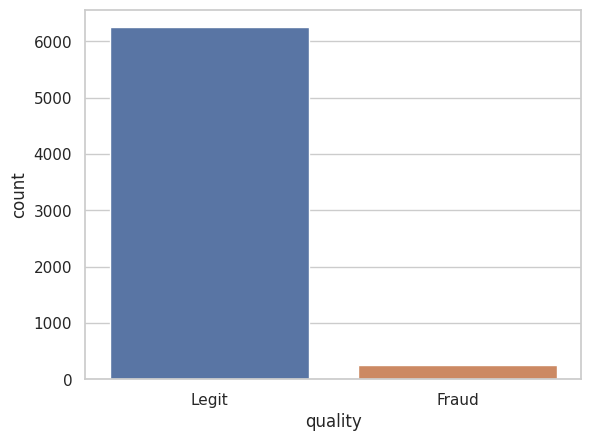

In [4]:
sns.countplot(data=df, x='quality', hue='quality');

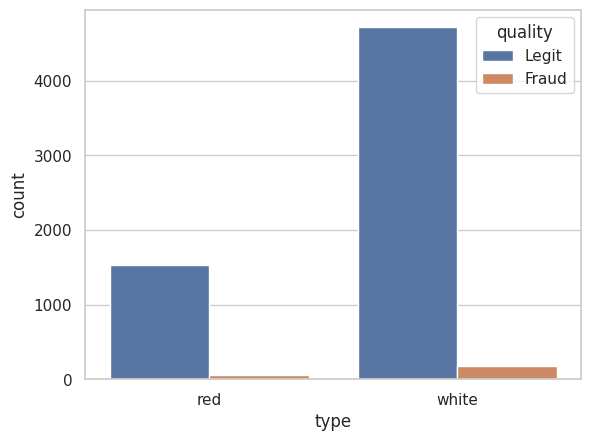

In [5]:
sns.countplot(data=df, x='type', hue='quality');

**We notice that the dataset is imbalanced**

**Let's check what percentage of red wines are Fraud? and what percentage of white wines are Fraud?**

In [6]:
reds = df[df['type'] == 'red']
reds_frauds = reds[reds['quality'] == 'Fraud']
red_frauds_share = (len(reds_frauds) * 100) / len(reds)
print('Percentage of fraud in Red Wines:', round(red_frauds_share, 2))

whites = df[df['type'] == 'white']
whites_frauds = whites[whites['quality'] == 'Fraud']
whites_frauds_share = (len(whites_frauds) * 100) / len(whites)
print('Percentage of fraud in White Wines:', round(whites_frauds_share, 2))

Percentage of fraud in Red Wines: 3.94
Percentage of fraud in White Wines: 3.74


**Let's calculate the correlation between the various features and the "quality" column. To do this we may need to map the column to 0 and 1 instead of a string.**

In [7]:
df['Quality_num'] = df['quality'].map({'Legit': 0, 'Fraud': 1})
correlations = df.drop(['quality', 'type'], axis=1).corr()['Quality_num'].sort_values()[:-1]
correlations

,Quality_num
free sulfur dioxide,-0.085204
citric acid,-0.061789
alcohol,-0.051141
residual sugar,-0.048756
total sulfur dioxide,-0.035252
sulphates,-0.034046
density,0.016351
pH,0.020107
fixed acidity,0.021794
chlorides,0.034499


Let's create a bar plot of the correlation values between other features and the **quality** feature

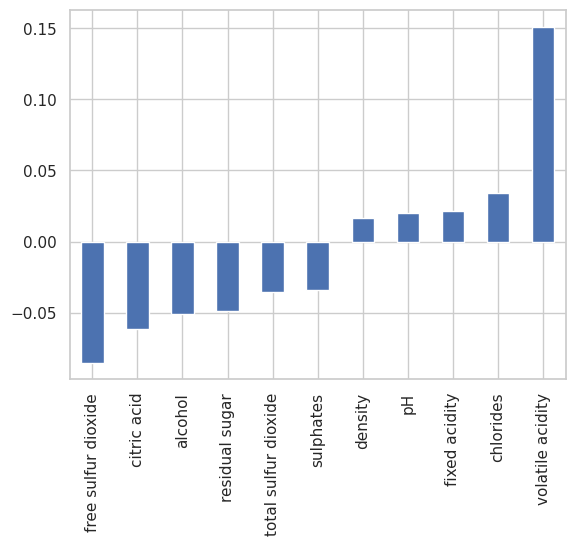

In [8]:
correlations.plot(kind='bar');

Let's create a clustermap with seaborn to explore the relationships between variables.

### Machine Learning Model development

Let's first convert the categorical column `type` from a string (`red` or `white`) to dummy variables. After that we will split the data, scale the features, and train two classifiers with a few hyperparameter variations.

In [9]:
df = df.drop('Quality_num', axis=1)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [10]:
df['type'] = pd.get_dummies(df['type'], drop_first=True, dtype='int')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,0


In [11]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101, stratify=y)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

Now, let's create an instance of a Support Vector Machine classifier. However, we already know that the classes are unbalanced. In order to help alleviate this issue, we can automatically adjust weights inversely proportional to class frequencies in the input data with a argument call in the SVC() call. The argument is **class_weight**

In [12]:
model = SVC(class_weight='balanced')

Let's use a GridSearchCV to run a grid search for the best C, gamma and kernel parameters.

In [13]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
grid_model = GridSearchCV(model, param_grid)
grid_model.fit(scaled_X_train, y_train)
grid_model.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

### Model evaluation

After creating and training the SVC model with the best configurations, we evaluate the model on the hold-out test set using accuracy, precision, recall, F1-score, and a confusion matrix.

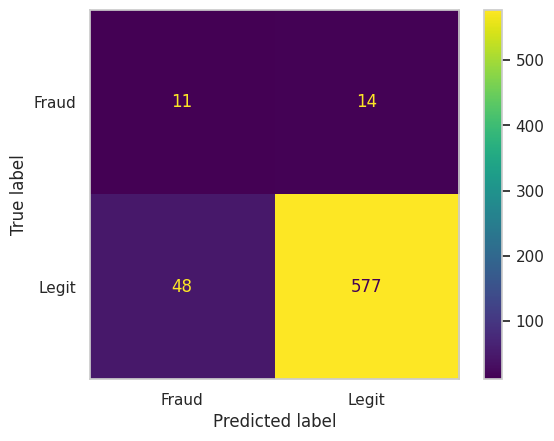

In [14]:
y_pred = grid_model.predict(scaled_X_test)
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_X_test, y_test);
plt.grid(False)

The SVC model is a good baseline because it handles nonlinear boundaries well when an RBF kernel is selected, but on this imbalanced dataset it may still miss many of the fraud cases. That is why we also test a second classical model.

### Second classical model

A random forest gives us a tree-based comparison point. This is useful because it does not require scaling and it can capture interactions between features that a margin-based method may miss.

In [15]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=101)
rf_param_grid = {'n_estimators': [100, 300, 500], 'max_depth': [None, 8, 12]}
rf_grid = GridSearchCV(rf_model, rf_param_grid)
rf_grid.fit(scaled_X_train, y_train)
rf_grid.best_params_

{'max_depth': None, 'n_estimators': 100}

There is a big probability that the model has overfited as there was no limit on the tree's depths (Because the choosen max_depth is **None**). For that le'ts first check the depth of each tree, and after that, compare the accuracy on the training data vs on the testing data.

In [16]:
max_depth_list = []
for tree in rf_grid.best_estimator_.estimators_:
    max_depth_list.append(tree.tree_.max_depth)
print(max_depth_list)

[23, 25, 30, 24, 22, 22, 27, 19, 24, 27, 24, 22, 26, 23, 22, 20, 19, 22, 22, 19, 19, 25, 23, 22, 20, 18, 20, 19, 26, 21, 22, 22, 21, 25, 19, 18, 26, 25, 21, 20, 24, 25, 19, 25, 20, 22, 25, 21, 26, 25, 21, 20, 21, 30, 23, 22, 23, 26, 20, 21, 18, 23, 20, 24, 20, 22, 21, 27, 26, 26, 23, 24, 20, 24, 21, 23, 25, 28, 20, 20, 25, 22, 28, 22, 18, 21, 20, 19, 22, 30, 22, 24, 22, 24, 20, 26, 21, 21, 21, 24]


In [17]:
train_acc = accuracy_score(y_train, rf_grid.predict(scaled_X_train))
test_acc = accuracy_score(y_test, rf_grid.predict(scaled_X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.9646153846153847


As we can see, although the difference between the training accuracy and the testing accuracy is small, we notice that **the model overfited** as the training accuracy is 100%. This means that the model learned every pattern of the training data, and will straggle to generalize on non-seen data. <p>To resolve that let's replace the **None** option by another one

In [18]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=101)
rf_param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [10, 15, 20]}
rf_grid = GridSearchCV(rf_model, rf_param_grid)
rf_grid.fit(scaled_X_train, y_train)
rf_grid.best_params_

{'max_depth': 15, 'n_estimators': 100}

In [19]:
train_acc = accuracy_score(y_train, rf_grid.predict(scaled_X_train))
test_acc = accuracy_score(y_test, rf_grid.predict(scaled_X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.963076923076923


The model is still overfitting. Let's reduce the max depth possible to 10 or lowwer

In [40]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=101)
rf_param_grid = {'n_estimators': [100], 'max_depth': [3, 5, 8]}
rf_grid = GridSearchCV(rf_model, rf_param_grid)
rf_grid.fit(scaled_X_train, y_train)
rf_grid.best_params_

{'max_depth': 8, 'n_estimators': 100}

In [41]:
train_acc = accuracy_score(y_train, rf_grid.predict(scaled_X_train))
test_acc = accuracy_score(y_test, rf_grid.predict(scaled_X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9763981528989225
Test Accuracy: 0.9538461538461539


Finally, when the max depth is 8, the training accuracy is 97% (not 100) and train vs test accuracy difference is minimal (2%)

### Classical model comparison

We compare the two classical models on the same test split so that the metrics are directly comparable.

In [42]:
rf_pred = rf_grid.predict(scaled_X_test)

svc_accuracy = accuracy_score(y_test, y_pred)
svc_precision = precision_score(y_test, y_pred, pos_label='Fraud', zero_division=0)
svc_recall = recall_score(y_test, y_pred, pos_label='Fraud', zero_division=0)
svc_f1 = f1_score(y_test, y_pred, pos_label='Fraud', zero_division=0)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, pos_label='Fraud', zero_division=0)
rf_recall = recall_score(y_test, rf_pred, pos_label='Fraud', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, pos_label='Fraud', zero_division=0)

results = pd.DataFrame({
    'Model': ['SVC', 'Random Forest'],
    'Accuracy': [svc_accuracy, rf_accuracy],
    'Precision': [svc_precision, rf_precision],
    'Recall': [svc_recall, rf_recall],
    'F1': [svc_f1, rf_f1]
})
results

,Model,Accuracy,Precision,Recall,F1
0,SVC,0.904615,0.186441,0.44,0.261905
1,Random Forest,0.953846,0.333333,0.20,0.250000


### Classical confusion matrices

The confusion matrix helps us see how many fraud cases were missed and how many legitimate wines were flagged incorrectly.

SVC classification report
              precision    recall  f1-score   support

       Fraud       0.19      0.44      0.26        25
       Legit       0.98      0.92      0.95       625

    accuracy                           0.90       650
   macro avg       0.58      0.68      0.61       650
weighted avg       0.95      0.90      0.92       650



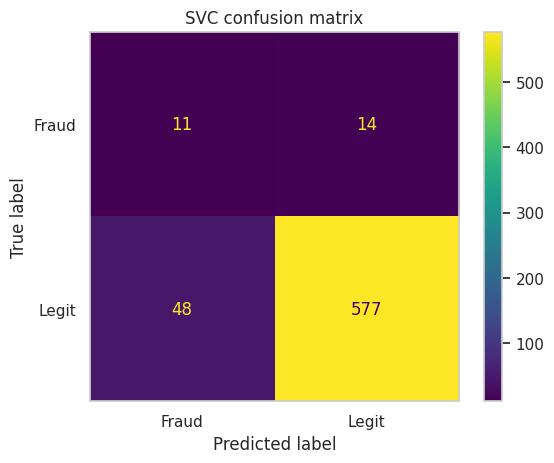

In [45]:
ConfusionMatrixDisplay.from_estimator(grid_model, scaled_X_test, y_test);
plt.title('SVC confusion matrix')
plt.grid(False)

print('SVC classification report')
print(classification_report(y_test, y_pred))

Random Forest classification report
              precision    recall  f1-score   support

       Fraud       0.33      0.20      0.25        25
       Legit       0.97      0.98      0.98       625

    accuracy                           0.95       650
   macro avg       0.65      0.59      0.61       650
weighted avg       0.94      0.95      0.95       650



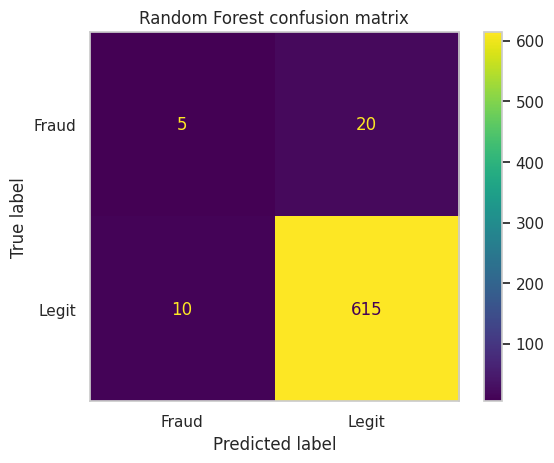

In [46]:
ConfusionMatrixDisplay.from_estimator(rf_grid, scaled_X_test, y_test);
plt.title('Random Forest confusion matrix')
plt.grid(False)

print('Random Forest classification report')
print(classification_report(y_test, rf_pred))

Now let's compare the two models and clearly articulate the strengths and the weaknesses of each of them.

**1. SVC (Support Vector Classifier)**

**Strengths:**

- **Better Recall for Fraud:** It identified 11 out of 25 fraud cases (Recall = 0.44). This is significantly higher than the Random Forest model, meaning it is better at "catching" actual fraud.  

**Weaknesses:**

- **Low Precision for Fraud:** With a precision of 0.19, it produces a high number of false positives (48 legit wines were incorrectly flagged as fraud). This would likely result in too many false alarms in a real-world scenario.

- **Lower Overall Accuracy:** 0.90 compared to the Random Forest's 0.95.

**2. Random Forest**  

**Strengths:**  

- **Higher Precision for Fraud:** It is more "trustworthy" when it does flag a wine as fraud (Precision = 0.33). It makes fewer false accusations than the SVC.

- **Better Overall Accuracy:** 0.95, largely because it is very good at correctly identifying "Legit" wines.  

**Weaknesses:**  

- **Poor Recall for Fraud:** It only caught 5 out of 25 fraud cases (Recall = 0.20). It misses the vast majority of fraudulent wines, which is generally the worst outcome for a fraud detection system.

**Conclusion & Recomandations:**  

- If our priority is **to catch as much fraud as possible** (even at the cost of more false alarms), the SVC is currently the better choice because of its higher recall.  

- If our priority is **to avoid false accusations** (e.g., we don't want to bother legitimate sellers), the Random Forest is better, but it is currently failing to detect 80% of the fraud.

### Neural network from scratch

The neural network below is implemented from sratch in NumPy. It follows the same style as the examples in video lectures on Canvas: simple layer classes, explicit forward passes, and manual weight updates. The task is binary classification, so the output layer uses a sigmoid activation and the loss is binary cross-entropy.

In [63]:
nn_df = pd.read_csv('./data/wine_fraud.csv')
#nn_df = pd.read_csv('/content/wine_fraud.csv')

nn_df['Quality_num'] = nn_df['quality'].map({'Legit': 0, 'Fraud': 1})

# Encode 'type' as a numeric feature and build X/y for the NN path.
X = pd.get_dummies(nn_df.drop(['quality', 'Quality_num'], axis=1), columns=['type'], drop_first=True, dtype='int')
y = nn_df['Quality_num']

# Train/validation/test splits (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=101, stratify=y_train)

# Scale numeric features
scaler_nn = StandardScaler()
scaled_X_train = scaler_nn.fit_transform(X_train)
scaled_X_val = scaler_nn.transform(X_val)
scaled_X_test = scaler_nn.transform(X_test)

print('Train shape:', scaled_X_train.shape)
print('Validation shape:', scaled_X_val.shape)
print('Test shape:', scaled_X_test.shape)

# Class counts and a capped manual class-weight strategy.
fraud_count = int((y_train == 1).sum())
legit_count = int((y_train == 0).sum())
print('Fraud in train set:', fraud_count)

# Cap the fraud weight so the network does not collapse into predicting Fraud for everything.
fraud_weight = min(12.5, legit_count / max(fraud_count, 1))
class_weights = {
    0: 1.0,
    1: fraud_weight,
}

# Per-sample training weights normalized to mean 1.
train_sample_weights = np.where(y_train.to_numpy() == 1, class_weights[1], class_weights[0]).astype(float)
train_sample_weights = train_sample_weights / train_sample_weights.mean()

# Validation weights are uniform (we tune thresholds on validation predictions)
val_weights = np.ones(len(y_val), dtype=float)

# Toggle to use SMOTE oversampling on the training set instead of weighted loss.
USE_SMOTE = True

Train shape: (5262, 12)
Validation shape: (585, 12)
Test shape: (650, 12)
Fraud in train set: 199


The next cell defines the layer, activation, and loss classes. This keeps the network readable and makes the backward pass easy to modify later if needed.

In [64]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons, init='he', bias_init=0.0):
        if init == 'he':
            self.weights = np.random.randn(n_inputs, n_neurons) * np.sqrt(2.0 / n_inputs)
        elif init == 'small':
            self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        else:
            self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.full((1, n_neurons), bias_init, dtype=float)

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)


class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0


class Activation_Sigmoid:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))

    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output


class Loss:
    def calculate(self, output, y, sample_weights=None):
        sample_losses = self.forward(output, y, sample_weights)
        return np.mean(sample_losses)


class Loss_BinaryCrossentropy(Loss):
    def forward(self, y_pred, y_true, sample_weights=None):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        y_true = y_true.reshape(-1, 1)
        losses = -(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        if sample_weights is not None:
            losses = losses * sample_weights.reshape(-1, 1)
        return losses.reshape(samples)

    def backward(self, y_pred, y_true, sample_weights=None):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        y_true = y_true.reshape(-1, 1)
        dinputs = -(y_true / y_pred_clipped - (1 - y_true) / (1 - y_pred_clipped))
        if sample_weights is not None:
            dinputs = dinputs * sample_weights.reshape(-1, 1)
        self.dinputs = dinputs / samples

### Training the scratch network

We will run a few experiments by changing the number of hidden units and the learning rate. The goal is to show that the model learns over epochs and to compare the final test performance across settings.

In [65]:
def run_experiment(train_x, train_y, train_weights, hidden1, hidden2, learning_rate, epochs, patience=60, min_delta=1e-4, reduce_lr_patience=20, lr_decay=0.7, min_lr=5e-5, use_smote=False):
    np.random.seed(101)

    train_x_array = np.asarray(train_x)
    train_y_array = np.asarray(train_y).ravel()
    val_x_array = np.asarray(scaled_X_val)
    val_y_array = np.asarray(y_val).ravel()

    if use_smote:
        output_bias = 0.0
    else:
        fraud_rate = float(train_y_array.mean())
        output_bias = np.log((fraud_rate + 1e-7) / (1 - fraud_rate + 1e-7))

    dense1 = Layer_Dense(train_x_array.shape[1], hidden1, init='he')
    activation1 = Activation_ReLU()
    dense2 = Layer_Dense(hidden1, hidden2, init='he')
    activation2 = Activation_ReLU()
    dense3 = Layer_Dense(hidden2, 1, init='small', bias_init=output_bias)
    activation3 = Activation_Sigmoid()
    loss_function = Loss_BinaryCrossentropy()

    train_weights_array = np.asarray(train_weights, dtype=float)
    val_weights_local = val_weights

    # Adam optimizer state for the dense layers.
    adam_state = {
        'dense1_weights_m': np.zeros_like(dense1.weights),
        'dense1_weights_v': np.zeros_like(dense1.weights),
        'dense1_biases_m': np.zeros_like(dense1.biases),
        'dense1_biases_v': np.zeros_like(dense1.biases),
        'dense2_weights_m': np.zeros_like(dense2.weights),
        'dense2_weights_v': np.zeros_like(dense2.weights),
        'dense2_biases_m': np.zeros_like(dense2.biases),
        'dense2_biases_v': np.zeros_like(dense2.biases),
        'dense3_weights_m': np.zeros_like(dense3.weights),
        'dense3_weights_v': np.zeros_like(dense3.weights),
        'dense3_biases_m': np.zeros_like(dense3.biases),
        'dense3_biases_v': np.zeros_like(dense3.biases),
    }
    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8
    adam_step = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'train_fraud_recall': [],
        'val_fraud_recall': [],
        'train_fraud_f1': [],
        'val_fraud_f1': [],
        'learning_rate': [],
    }

    best_val_loss = np.inf
    best_state = None
    epochs_without_improvement = 0
    epochs_without_lr_drop = 0
    current_learning_rate = learning_rate

    for epoch in range(epochs):
        dense1.forward(train_x_array)
        activation1.forward(dense1.output)
        dense2.forward(activation1.output)
        activation2.forward(dense2.output)
        dense3.forward(activation2.output)
        activation3.forward(dense3.output)

        train_prob = activation3.output
        train_pred = (train_prob >= 0.5).astype(int).ravel()
        train_loss = loss_function.calculate(train_prob, train_y_array, train_weights_array)
        train_acc = accuracy_score(train_y_array, train_pred)

        dense1_val = Layer_Dense(val_x_array.shape[1], hidden1, init='he')
        dense1_val.weights = dense1.weights.copy()
        dense1_val.biases = dense1.biases.copy()
        activation1_val = Activation_ReLU()
        dense2_val = Layer_Dense(hidden1, hidden2, init='he')
        dense2_val.weights = dense2.weights.copy()
        dense2_val.biases = dense2.biases.copy()
        activation2_val = Activation_ReLU()
        dense3_val = Layer_Dense(hidden2, 1, init='small')
        dense3_val.weights = dense3.weights.copy()
        dense3_val.biases = dense3.biases.copy()
        activation3_val = Activation_Sigmoid()

        dense1_val.forward(val_x_array)
        activation1_val.forward(dense1_val.output)
        dense2_val.forward(activation1_val.output)
        activation2_val.forward(dense2_val.output)
        dense3_val.forward(activation2_val.output)
        activation3_val.forward(dense3_val.output)
        val_prob = activation3_val.output
        val_pred = (val_prob >= 0.5).astype(int).ravel()
        val_loss = loss_function.calculate(val_prob, val_y_array, val_weights_local)
        val_acc = accuracy_score(val_y_array, val_pred)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        history['train_fraud_recall'].append(recall_score(train_y_array, train_pred, pos_label=1, zero_division=0))
        history['val_fraud_recall'].append(recall_score(val_y_array, val_pred, pos_label=1, zero_division=0))
        history['train_fraud_f1'].append(f1_score(train_y_array, train_pred, pos_label=1, zero_division=0))
        history['val_fraud_f1'].append(f1_score(val_y_array, val_pred, pos_label=1, zero_division=0))
        history['learning_rate'].append(current_learning_rate)

        loss_function.backward(train_prob, train_y_array, train_weights_array)
        activation3.backward(loss_function.dinputs)
        dense3.backward(activation3.dinputs)
        activation2.backward(dense3.dinputs)
        dense2.backward(activation2.dinputs)
        activation1.backward(dense2.dinputs)
        dense1.backward(activation1.dinputs)

        adam_step += 1
        for layer_name, layer in [('dense1', dense1), ('dense2', dense2), ('dense3', dense3)]:
            weights_m_key = f'{layer_name}_weights_m'
            weights_v_key = f'{layer_name}_weights_v'
            biases_m_key = f'{layer_name}_biases_m'
            biases_v_key = f'{layer_name}_biases_v'

            adam_state[weights_m_key] = beta1 * adam_state[weights_m_key] + (1 - beta1) * layer.dweights
            adam_state[weights_v_key] = beta2 * adam_state[weights_v_key] + (1 - beta2) * (layer.dweights ** 2)
            adam_state[biases_m_key] = beta1 * adam_state[biases_m_key] + (1 - beta1) * layer.dbiases
            adam_state[biases_v_key] = beta2 * adam_state[biases_v_key] + (1 - beta2) * (layer.dbiases ** 2)

            weights_m_hat = adam_state[weights_m_key] / (1 - beta1 ** adam_step)
            weights_v_hat = adam_state[weights_v_key] / (1 - beta2 ** adam_step)
            biases_m_hat = adam_state[biases_m_key] / (1 - beta1 ** adam_step)
            biases_v_hat = adam_state[biases_v_key] / (1 - beta2 ** adam_step)

            layer.weights -= current_learning_rate * weights_m_hat / (np.sqrt(weights_v_hat) + epsilon)
            layer.biases -= current_learning_rate * biases_m_hat / (np.sqrt(biases_v_hat) + epsilon)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = {
                'dense1_weights': dense1.weights.copy(),
                'dense1_biases': dense1.biases.copy(),
                'dense2_weights': dense2.weights.copy(),
                'dense2_biases': dense2.biases.copy(),
                'dense3_weights': dense3.weights.copy(),
                'dense3_biases': dense3.biases.copy(),
            }
            epochs_without_improvement = 0
            epochs_without_lr_drop = 0
        else:
            epochs_without_improvement += 1
            epochs_without_lr_drop += 1
            if epochs_without_lr_drop >= reduce_lr_patience and current_learning_rate > min_lr:
                current_learning_rate = max(current_learning_rate * lr_decay, min_lr)
                epochs_without_lr_drop = 0

        if epochs_without_improvement >= patience:
            break

    if best_state is not None:
        dense1.weights = best_state['dense1_weights']
        dense1.biases = best_state['dense1_biases']
        dense2.weights = best_state['dense2_weights']
        dense2.biases = best_state['dense2_biases']
        dense3.weights = best_state['dense3_weights']
        dense3.biases = best_state['dense3_biases']

    return {
        'dense1': dense1,
        'activation1': activation1,
        'dense2': dense2,
        'activation2': activation2,
        'dense3': dense3,
        'activation3': activation3,
        'history': history,
        'learning_rate': learning_rate,
        'hidden1': hidden1,
        'hidden2': hidden2,
        'epochs': epochs,
        'loss_function': loss_function,
        'train_weights': train_weights_array,
        'val_weights': val_weights_local,
        'best_val_loss': best_val_loss,
    }


def predict_network(model, X_input):
    dense1 = model['dense1']
    activation1 = Activation_ReLU()
    dense2 = model['dense2']
    activation2 = Activation_ReLU()
    dense3 = model['dense3']
    activation3 = Activation_Sigmoid()

    dense1.forward(X_input)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)
    dense3.forward(activation2.output)
    activation3.forward(dense3.output)
    return activation3.output


if USE_SMOTE:
    smote = SMOTE(random_state=101)
    X_train_fit, y_train_fit = smote.fit_resample(scaled_X_train, y_train)
    train_weights_fit = np.ones(len(y_train_fit), dtype=float)
    training_strategy = 'SMOTE oversampling'
else:
    X_train_fit = scaled_X_train
    y_train_fit = y_train.to_numpy()
    train_weights_fit = train_sample_weights
    training_strategy = 'Weighted binary cross-entropy'

configs = [
    {'hidden1': 8, 'hidden2': 4, 'learning_rate': 0.001, 'epochs': 400},
    {'hidden1': 12, 'hidden2': 6, 'learning_rate': 0.001, 'epochs': 500},
    {'hidden1': 16, 'hidden2': 8, 'learning_rate': 0.0005, 'epochs': 600},
]

nn_results = []
trained_models = []

for config in configs:
    model = run_experiment(
        X_train_fit,
        y_train_fit,
        train_weights_fit,
        config['hidden1'],
        config['hidden2'],
        config['learning_rate'],
        config['epochs'],
        use_smote=USE_SMOTE,
    )
    y_prob = predict_network(model, scaled_X_test)
    y_pred_nn = (y_prob > 0.5).astype(int).ravel()
    nn_results.append({
        'hidden1': config['hidden1'],
        'hidden2': config['hidden2'],
        'learning_rate': config['learning_rate'],
        'epochs': config['epochs'],
        'Accuracy': accuracy_score(y_test, y_pred_nn),
        'Precision': precision_score(y_test, y_pred_nn, zero_division=0),
        'Recall': recall_score(y_test, y_pred_nn, zero_division=0),
        'F1': f1_score(y_test, y_pred_nn, zero_division=0)
    })
    trained_models.append(model)

nn_results_df = pd.DataFrame(nn_results)

### Scratch network results

The table below compares the three training runs. The best model will be used for the final test evaluation and for the learning curves.

In [66]:
nn_results_df

,hidden1,hidden2,learning_rate,epochs,Accuracy,Precision,Recall,F1
0,8,4,0.0010,400,0.769231,0.086093,0.52,0.147727
1,12,6,0.0010,500,0.756923,0.096970,0.64,0.168421
2,16,8,0.0005,600,0.938462,0.000000,0.00,0.000000


### Learning curves and test evaluation

We now select the best run, plot its learning curves, and check how it performs on the test set.

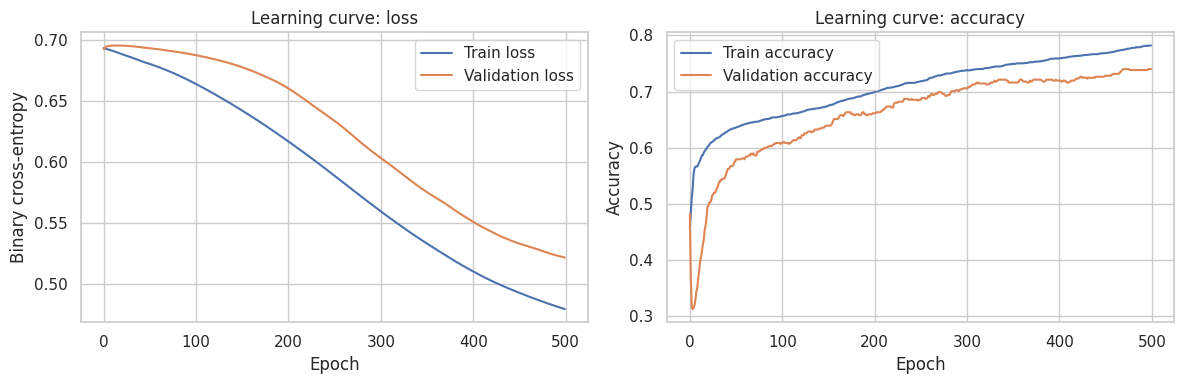

Best scratch NN settings:
hidden1           12.000000
hidden2            6.000000
learning_rate      0.001000
epochs           500.000000
Accuracy           0.756923
Precision          0.096970
Recall             0.640000
F1                 0.168421
Name: 1, dtype: float64

Validation AUC (raw): 0.7506055223639594
Score direction: as-is
Validation threshold (best Fraud F1): 0.8500000000000001
Validation threshold (best Fraud Recall): 0.0001

Using decision threshold: 0.8500000000000001


In [68]:
best_nn_index = nn_results_df['F1'].idxmax()
best_nn_model = trained_models[best_nn_index]
best_nn_row = nn_results_df.loc[best_nn_index]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(best_nn_model['history']['train_loss'], label='Train loss')
ax[0].plot(best_nn_model['history']['val_loss'], label='Validation loss')
ax[0].set_title('Learning curve: loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Binary cross-entropy')
ax[0].legend()

ax[1].plot(best_nn_model['history']['train_accuracy'], label='Train accuracy')
ax[1].plot(best_nn_model['history']['val_accuracy'], label='Validation accuracy')
ax[1].set_title('Learning curve: accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()

# Threshold sweep utility (validation)
def sweep_thresholds(y_true, y_prob, thresholds=None):
    if thresholds is None:
        low_band = np.linspace(0.0001, 0.01, 100)
        mid_band = np.linspace(0.015, 0.10, 18)
        high_band = np.linspace(0.15, 0.90, 16)
        thresholds = np.unique(np.concatenate([low_band, mid_band, high_band]))
    rows = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int).ravel()
        rows.append({
            'threshold': threshold,
            'fraud_precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            'fraud_recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            'fraud_f1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        })
    return pd.DataFrame(rows)

# Select threshold on validation.
val_prob_nn_raw = predict_network(best_nn_model, scaled_X_val)
val_auc_raw = roc_auc_score(y_val, val_prob_nn_raw)
score_flipped = val_auc_raw < 0.5
val_prob_nn = 1 - val_prob_nn_raw if score_flipped else val_prob_nn_raw
threshold_table = sweep_thresholds(y_val.to_numpy(), val_prob_nn)
best_f1_threshold = threshold_table.loc[threshold_table['fraud_f1'].idxmax(), 'threshold']
best_recall_threshold = threshold_table.loc[threshold_table['fraud_recall'].idxmax(), 'threshold']

# Choose the threshold that maximizes Fraud F1 by default (you can pick best_recall_threshold instead)
decision_threshold = float(best_f1_threshold)

print('Best scratch NN settings:')
print(best_nn_row)
print('\nValidation AUC (raw):', val_auc_raw)
print('Score direction:', 'flipped' if score_flipped else 'as-is')
print('Validation threshold (best Fraud F1):', best_f1_threshold)
print('Validation threshold (best Fraud Recall):', best_recall_threshold)
print('\nUsing decision threshold:', decision_threshold)

# Test evaluation using selected threshold.
y_prob_nn_test_raw = predict_network(best_nn_model, scaled_X_test)
y_prob_nn_test = 1 - y_prob_nn_test_raw if score_flipped else y_prob_nn_test_raw
y_pred_nn = (y_prob_nn_test >= decision_threshold).astype(int).ravel()



Fraud-focused classification report
              precision    recall  f1-score   support

       Legit       0.97      0.99      0.98       625
       Fraud       0.31      0.16      0.21        25

    accuracy                           0.95       650
   macro avg       0.64      0.57      0.59       650
weighted avg       0.94      0.95      0.95       650



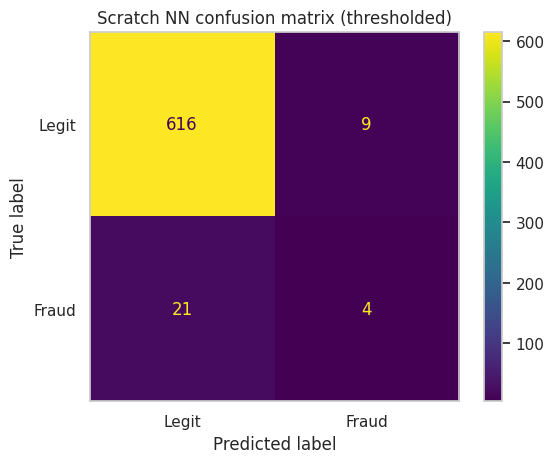

,Threshold,Accuracy,Fraud precision,Fraud recall,Fraud F1,Fraud ROC AUC
0,0.85,0.953846,0.307692,0.16,0.210526,0.756032


,threshold,fraud_precision,fraud_recall,fraud_f1
132,0.85,0.428571,0.272727,0.333333
131,0.80,0.318182,0.318182,0.318182
129,0.70,0.181818,0.454545,0.259740
130,0.75,0.189189,0.318182,0.237288
128,0.65,0.150685,0.500000,0.231579


In [70]:
print('\nFraud-focused classification report')
print(classification_report(y_test, y_pred_nn, target_names=['Legit', 'Fraud'], zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=['Legit', 'Fraud'])
plt.title('Scratch NN confusion matrix (thresholded)')
plt.grid(False)
plt.show()

# Summary metrics table
summary = pd.DataFrame([{
    'Threshold': decision_threshold,
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Fraud precision': precision_score(y_test, y_pred_nn, pos_label=1, zero_division=0),
    'Fraud recall': recall_score(y_test, y_pred_nn, pos_label=1, zero_division=0),
    'Fraud F1': f1_score(y_test, y_pred_nn, pos_label=1, zero_division=0),
    'Fraud ROC AUC': roc_auc_score(y_test, y_prob_nn_test)
}])

display(summary)

display(threshold_table.sort_values('fraud_f1', ascending=False).head(5))

**Interpretation: Scratch Neural Network Results**

- **Training behaviour:** the learning curves show steadily decreasing training and validation loss, indicating the network is able to fit the data without obvious overfitting during the recorded runs.

- **Overall accuracy is high because the dataset is heavily imbalanced, but this metric is misleading for fraud detection:** the network detects only a small fraction of fraud cases (low true positives) while correctly labelling most legitimate samples.

- **Precision / Recall trade-off:** threshold tuning increased fraud recall at the cost of precision (many false positives). Selecting a very low decision threshold can recover more frauds but produces many false alarms.

- **Imbalance handling tried:** class weighting and SMOTE improved training stability but gave only modest gains in minority-class F1; the model still struggles to separate frauds from legits reliably.

### Decision boundary illustration

A decision boundary is easiest to visualize in two dimensions, so we project the processed data to the first two principal components and train a small network for illustration only. The main evaluation still uses the full feature set.

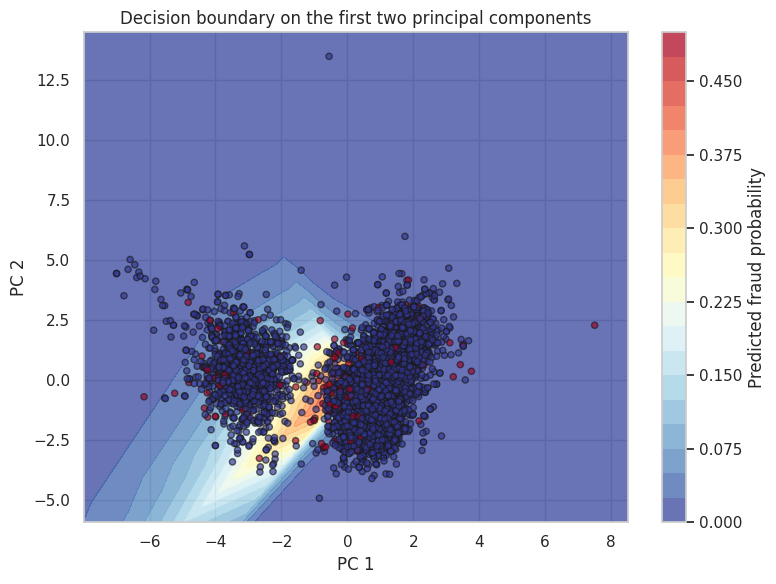

In [71]:
pca = PCA(n_components=2, random_state=101)
X_vis_train = pca.fit_transform(scaled_X_train)
X_vis_val = pca.transform(scaled_X_val)

vis_dense1 = Layer_Dense(2, 8)
vis_activation1 = Activation_ReLU()
vis_dense2 = Layer_Dense(8, 4)
vis_activation2 = Activation_ReLU()
vis_dense3 = Layer_Dense(4, 1)
vis_activation3 = Activation_Sigmoid()
vis_loss = Loss_BinaryCrossentropy()

vis_train_weights = np.ones(len(y_train), dtype=float)
vis_val_weights = np.ones(len(y_val), dtype=float)

for epoch in range(120):
    vis_dense1.forward(X_vis_train)
    vis_activation1.forward(vis_dense1.output)
    vis_dense2.forward(vis_activation1.output)
    vis_activation2.forward(vis_dense2.output)
    vis_dense3.forward(vis_activation2.output)
    vis_activation3.forward(vis_dense3.output)

    vis_loss.backward(vis_activation3.output, y_train.values, vis_train_weights)
    vis_activation3.backward(vis_loss.dinputs)
    vis_dense3.backward(vis_activation3.dinputs)
    vis_activation2.backward(vis_dense3.dinputs)
    vis_dense2.backward(vis_activation2.dinputs)
    vis_activation1.backward(vis_dense2.dinputs)
    vis_dense1.backward(vis_activation1.dinputs)

    vis_dense1.weights -= 0.01 * vis_dense1.dweights
    vis_dense1.biases -= 0.01 * vis_dense1.dbiases
    vis_dense2.weights -= 0.01 * vis_dense2.dweights
    vis_dense2.biases -= 0.01 * vis_dense2.dbiases
    vis_dense3.weights -= 0.01 * vis_dense3.dweights
    vis_dense3.biases -= 0.01 * vis_dense3.dbiases

xx, yy = np.meshgrid(
    np.linspace(X_vis_train[:, 0].min() - 1, X_vis_train[:, 0].max() + 1, 250),
    np.linspace(X_vis_train[:, 1].min() - 1, X_vis_train[:, 1].max() + 1, 250)
)
mesh_points = np.c_[xx.ravel(), yy.ravel()]
vis_dense1.forward(mesh_points)
vis_activation1.forward(vis_dense1.output)
vis_dense2.forward(vis_activation1.output)
vis_activation2.forward(vis_dense2.output)
vis_dense3.forward(vis_activation2.output)
vis_activation3.forward(vis_dense3.output)
mesh_prob = vis_activation3.output.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, mesh_prob, levels=20, cmap='RdYlBu_r', alpha=0.75)
plt.colorbar(label='Predicted fraud probability')
plt.scatter(X_vis_train[:, 0], X_vis_train[:, 1], c=y_train, cmap='RdYlBu_r', edgecolor='k', s=20, alpha=0.65)
plt.title('Decision boundary on the first two principal components')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

### Comparison and discussion

The final comparison puts the strongest classical models next to the best scratch neural network. This is the most direct way to see how the two approaches differ on the same dataset and evaluation split.

In [72]:
comparison = pd.DataFrame({
    'Model': ['SVC', 'Random Forest', 'Scratch Neural Network'],
    'Accuracy': [svc_accuracy, rf_accuracy, accuracy_score(y_test, y_pred_nn)],
    'Precision': [svc_precision, rf_precision, precision_score(y_test, y_pred_nn, zero_division=0)],
    'Recall': [svc_recall, rf_recall, recall_score(y_test, y_pred_nn, zero_division=0)],
    'F1': [svc_f1, rf_f1, f1_score(y_test, y_pred_nn, zero_division=0)]
})
comparison

,Model,Accuracy,Precision,Recall,F1
0,SVC,0.904615,0.186441,0.44,0.261905
1,Random Forest,0.953846,0.333333,0.20,0.250000
2,Scratch Neural Network,0.953846,0.307692,0.16,0.210526


**Comparison and discussion (table shown above)**

- **Summary:** The comparison table shows all three models reach high overall accuracy, but this is dominated by the majority `Legit` class; minority `Fraud` performance is low across models.

- **Concrete numbers (from the table and report)**: SVC (Precision≈0.19, Recall≈0.44, F1≈0.26), Random Forest (Precision≈0.33, Recall≈0.20, F1≈0.25), Scratch NN (Precision≈0.31, Recall≈0.16, F1≈0.21).

- **Interpretation:** the Random Forest and the scratch NN trade precision vs recall differently. RF is slightly more precise, SVC higher recall but none deliver both high precision and high recall for fraud.

- **Business impact:** with only ~25 frauds in test, low recall means many frauds are missed (high false negative risk). If missing fraud is costly, we should choose a model/threshold that prioritises recall even if precision drops.

- **Why this happens:** severe class imbalance and a small number of positive examples make it hard for models to learn a reliable minority-class decision boundary without aggressive resampling, stronger regularization, or calibration.

## References

1. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
3. scikit-learn developers. (n.d.). *scikit-learn documentation*. https://scikit-learn.org/stable/
4. UCI Machine Learning Repository. (n.d.). *Wine Quality Data Set*. https://archive.ics.uci.edu/
5. Course-provided dataset: `data/wine_fraud.csv` in the Formative1 workspace.